In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## Data Loading and Cleaning

In [20]:
df = pd.read_csv('retail_sales_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())


Shape: (1000, 9)

First 5 rows:
   Transaction ID       Date Customer ID  Gender  Age Product Category  \
0               1 2023-11-24     CUST001    Male   34           Beauty   
1               2 2023-02-27     CUST002  Female   26         Clothing   
2               3 2023-01-13     CUST003    Male   50      Electronics   
3               4 2023-05-21     CUST004    Male   37         Clothing   
4               5 2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate Rows: 0


## Step 3: Descriptive Statistics

In [21]:
print("Basic Statistics:")
print(df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].describe().round(2))

print("\nMean sales: ", df['Total Amount'].mean())
print("Median Sales: ", df['Total Amount'].median())
print("Mode of Quantity: ", df['Quantity'].mode()[0])
print("Std Dev: ", df['Total Amount'].std().round(2))

print("\nCategory wise Total Sales:")
print(df.groupby('Product Category')['Total Amount'].sum())


Basic Statistics:
           Age  Quantity  Price per Unit  Total Amount
count  1000.00   1000.00         1000.00        1000.0
mean     41.39      2.51          179.89         456.0
std      13.68      1.13          189.68         560.0
min      18.00      1.00           25.00          25.0
25%      29.00      1.00           30.00          60.0
50%      42.00      3.00           50.00         135.0
75%      53.00      4.00          300.00         900.0
max      64.00      4.00          500.00        2000.0

Mean sales:  456.0
Median Sales:  135.0
Mode of Quantity:  4
Std Dev:  560.0

Category wise Total Sales:
Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


## Step 4: Time Series Analysis

In [22]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

monthly_sales = df.groupby('Month')['Total Amount'].sum()
print("Monthly Sales:")
print(monthly_sales)

print("\nBest Month:", monthly_sales.idxmax())
print("Besst Month Sales: ₹", monthly_sales.max())
print("Worst Month:", monthly_sales.idxmin())
print("Worst Month Sales: ₹", monthly_sales.min())

Monthly Sales:
Month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64

Best Month: 5
Besst Month Sales: ₹ 53150
Worst Month: 9
Worst Month Sales: ₹ 23620


## Step 5: Customer & Product Analysis

In [23]:
print("Gender Distribution")
print(df['Gender'].value_counts())

print("\nAvg Age of Customers:", round(df['Age'].mean(),1))

df['Age Group'] = pd.cut(df['Age'],
                         bins=[17,25,35,45,55,65],
                         labels=['18-25','26-35','36-45','46-55','56-65'])

print("\nSales by Age Group:")
print(df.groupby('Age Group', observed=True)['Total Amount'].sum())

print("\nCategory wise Avg Price:")
print(df.groupby('Product Category')['Price per Unit'].mean().round(2))

Gender Distribution
Gender
Female    510
Male      490
Name: count, dtype: int64

Avg Age of Customers: 41.4

Sales by Age Group:
Age Group
18-25     84550
26-35     98480
36-45     91870
46-55    100690
56-65     80410
Name: Total Amount, dtype: int64

Category wise Avg Price:
Product Category
Beauty         184.06
Clothing       174.29
Electronics    181.90
Name: Price per Unit, dtype: float64


## Step 6: Visualization

### a). Bar Graph

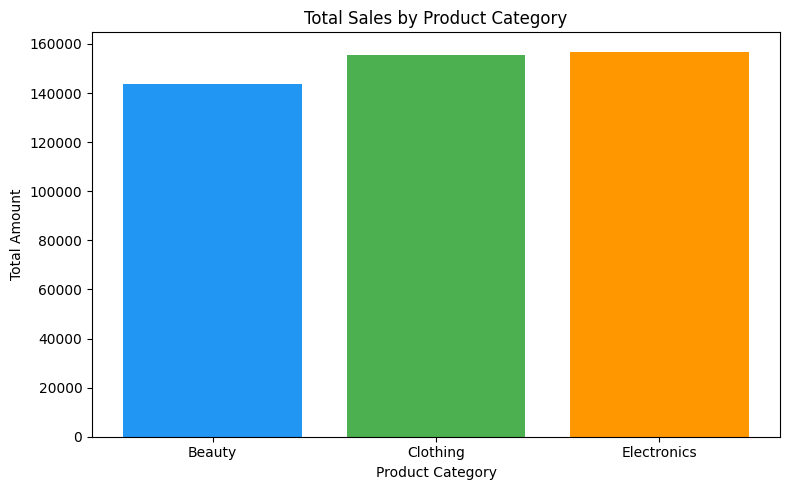

In [24]:
# Graph 1 - Sales by Category

plt.figure(figsize=(8,5))
Category_Sales = df.groupby('Product Category')['Total Amount'].sum()
plt.bar(Category_Sales.index, Category_Sales.values,
        color=['#2196F3', '#4CAF50', '#FF9800'])
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()


### b). Line Graph

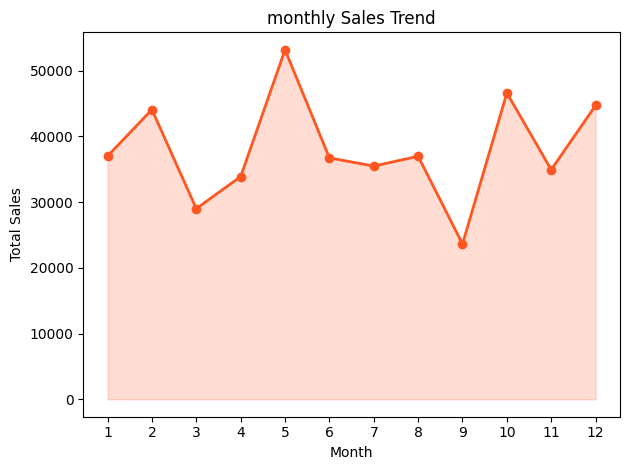

In [32]:
# Graph 2 - Monthly Sales Trend

plt.Figure(figsize=(10,5))
monthly_sales = df.groupby('Month')['Total Amount'].sum()
plt.plot(monthly_sales.index, monthly_sales.values,
         marker='o', color='#FF5722', linewidth=2)
plt.fill_between(monthly_sales.index, monthly_sales.values,
                 alpha=0.2, color='#FF5722')
plt.title('monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

### c). Heatmap

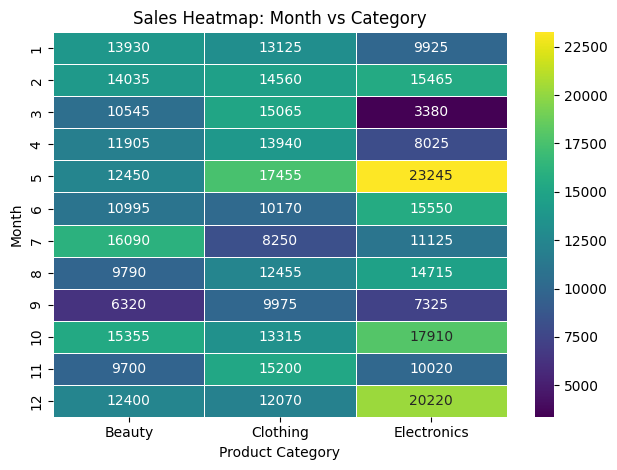

In [35]:
# Graph 3 - Heatmap

plt.Figure(figsize=(8,6))
heatmap_data = df.pivot_table(values='Total Amount',
                              index='Month',
                              columns='Product Category',
                              aggfunc='sum')
sns.heatmap(heatmap_data, cmap='viridis',
            annot=True, fmt='.0f', linewidths=0.5)
plt.title('Sales Heatmap: Month vs Category')
plt.tight_layout()
plt.show()

### D). Grouped Bar Chart

<Figure size 800x500 with 0 Axes>

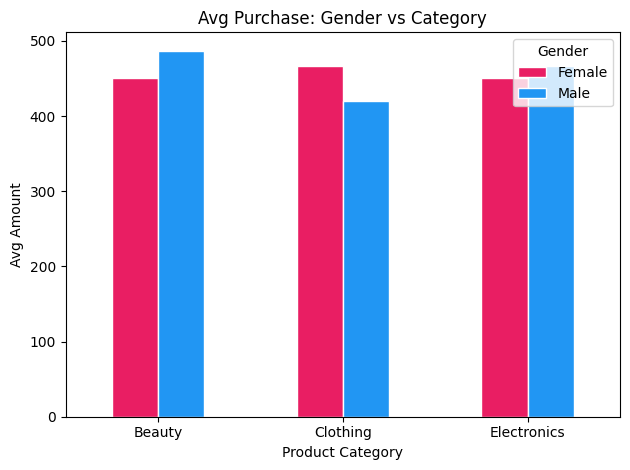

In [37]:
# Graph 4 - Gender vs Category

plt.figure(figsize=(8,5))
gender_category = df.pivot_table(values='Total Amount',
                                 index='Product Category',
                                 columns='Gender',
                                 aggfunc='mean')
gender_category.plot(kind='bar',
                     color=['#E91E63','#2196F3'],
                     edgecolor='white')
plt.title('Avg Purchase: Gender vs Category')
plt.xlabel('Product Category')
plt.ylabel('Avg Amount')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.  show()

# Step 7: Business Recommendations

In [39]:
# Step 7 : Business Recommendations

print("=" * 50)
print("BUSINESS RECOMMENDATIONS")
print("=" * 50)
print("""
1. FOCUS ON ELECTRONICS
      - Highest revenue category
      - Especially strong in May & December
      
2.BOOST SEPTEMBER SALES
      - Worst month for all categories
      - Run special discounts & offers
      
3. TARGET AGE GROUP  46-55
      - Highest spending age group
      - Design targeted campaigns
      
4. GENDER BASED MARKETING
      -  Promote Beauty to Male customers
      - Promote Clothing to Female customers
      
5. PEAK SEASON STRATEGY
      - May is best month
      - Ensure stock availability in May
""")
print("=" * 50)
print("EDA Complete! - Suraj kumar | OIB/J2/IP2626")
print("=" * 50)

BUSINESS RECOMMENDATIONS

1. FOCUS ON ELECTRONICS
      - Highest revenue category
      - Especially strong in May & December

2.BOOST SEPTEMBER SALES
      - Worst month for all categories
      - Run special discounts & offers

3. TARGET AGE GROUP  46-55
      - Highest spending age group
      - Design targeted campaigns

4. GENDER BASED MARKETING
      -  Promote Beauty to Male customers
      - Promote Clothing to Female customers

5. PEAK SEASON STRATEGY
      - May is best month
      - Ensure stock availability in May

EDA Complete! - Suraj kumar | OIB/J2/IP2626
